In [1]:
class SGD:
    def __init__(self, lr = 0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

In [2]:
import sys
sys.path.append('C:/Users/kohwo/deep-learning-from-scratch-master')

import numpy as np

import sys
import os

sys.path.append(os.pardir)
from common.functions import *
from common.gradient import numerical_gradient
from dataset.mnist import load_mnist

class TwoLayerNet:
    def __init__(self, input_size, hidden_size, output_size, weight_init_std=0.01):
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        return y

    def gradient(self, x, t):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']
        grads = {}

        batch_num = x.shape[0]

        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        y = softmax(a2)

        if t.ndim == 1:
            t = np.eye(y.shape[1])[t]        
            
        dy = (y - t) / batch_num
        grads['W2'] = np.dot(z1.T, dy)
        grads['b2'] = np.sum(dy, axis=0)

        da1 = np.dot(dy, W2.T)
        dz1 = sigmoid_grad(a1) * da1
        grads['W1'] = np.dot(x.T, dz1)
        grads['b1'] = np.sum(dz1, axis=0)

        return grads    

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1:
            t = np.argmax(t, axis=1)
            
        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

network = TwoLayerNet(784, 50, 10)
optimizer = SGD()

for i in range(10000):
    batch_size = 100
    batch_mask = np.random.choice(x_train.shape[0], batch_size)

    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]
    grads = network.gradient(x_batch, t_batch)
    params = network.params
    optimizer.update(params, grads)

In [3]:
class Momentum:

    """모멘텀 SGD"""

    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v ={}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)

            for key in params.keys():
                self.v[key] = self.momentum*self.v[key] - self.lr*grads[key]
                params[key] += self.v[key]

In [4]:
class AdaGrad:

    """AdaGrad"""

    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)

        for key in params.keys():
            self.h[key] += grads[key]*grads[key]
            params[key] -= self.lr*grads[key] / (np.sqrt(self.h[key]) + 1e-7)

In [5]:
class Adam:
    def __init__(self, lr=0.01, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.iter = 0
        self.m = None
        self.v = None

    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)

        self.iter += 1
        lr_t = self.lr * np.sqrt(1.0- self.beta2**self.iter) / (1.0- self.beta1**self.iter)

        for key in params.keys():
            self.m[key] += (1 - self.beta1) * (grads[key] - self.m[key])
            self.v[key] += (1 - self.beta2) * (grads[key]**2 - self.v[key])

            params[key] -= lr_t*self.m[key] / (np.sqrt(self.v[key]) + 1e-7)

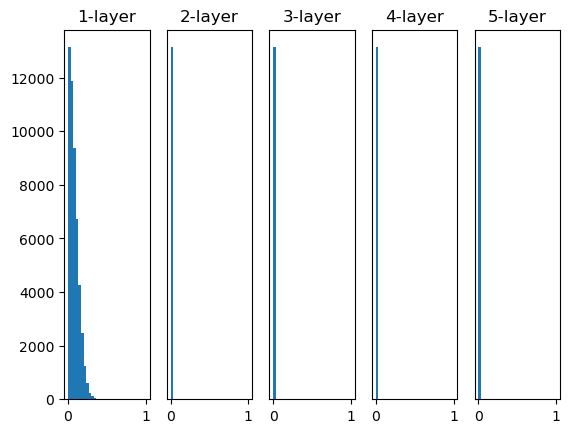

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.random.randn(1000, 100)
node_num = 100
hidden_layer_size = 5
activations = {}

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    w = np.random.randn(node_num, node_num) * 0.01
    a = np.dot(x, w)
    activations[i] = a

for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    if i != 0:
        plt.yticks([], [])
    plt.hist(a.flatten(), 30, range=(0,1))
plt.show()

In [7]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize = True)

x_train = x_train[:300]
t_train = t_train[:300]

network = TwoLayerNet(input_size=784, hidden_size=100, output_size=10, weight_init_std=0.1)
optimizer = SGD(lr=0.01)

max_epochs = 201
train_size = x_train.shape[0]
batch_size = 100

train_loss_list = []
train_acc_list = []
test_acc_list = []

iter_per_epoch = max(train_size / batch_size, 1)
epoch_cnt = 0

for i in range(100):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    grads = network.gradient(x_batch, t_batch)
    optimizer.update(network.params, grads)

    if i % iter_per_epoch == 0:
        train_acc = network.accuracy(x_train, t_train)
        test_acc = network.accuracy(x_test, t_test)
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)

        print("epoch:" + str(epoch_cnt) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc))

        epoch_cnt += 1
        if epoch_cnt >= max_epochs:
            break

epoch:0, train acc:0.07, test acc:0.0926
epoch:1, train acc:0.07666666666666666, test acc:0.0902
epoch:2, train acc:0.08333333333333333, test acc:0.0889
epoch:3, train acc:0.08666666666666667, test acc:0.092
epoch:4, train acc:0.11666666666666667, test acc:0.0981
epoch:5, train acc:0.12, test acc:0.1109
epoch:6, train acc:0.14, test acc:0.1226
epoch:7, train acc:0.16333333333333333, test acc:0.1392
epoch:8, train acc:0.16333333333333333, test acc:0.1508
epoch:9, train acc:0.16666666666666666, test acc:0.1588
epoch:10, train acc:0.16, test acc:0.1697
epoch:11, train acc:0.16333333333333333, test acc:0.1755
epoch:12, train acc:0.18333333333333332, test acc:0.1851
epoch:13, train acc:0.19, test acc:0.191
epoch:14, train acc:0.20333333333333334, test acc:0.2017
epoch:15, train acc:0.21, test acc:0.2047
epoch:16, train acc:0.21, test acc:0.2142
epoch:17, train acc:0.21, test acc:0.2102
epoch:18, train acc:0.20666666666666667, test acc:0.21
epoch:19, train acc:0.21333333333333335, test acc:0

In [8]:
class Dropout:
    def __init__(self,dropout_ratio=0.5):
        self.dropout_ratio=dropout_ratio
        self.mask=None

    def forward(self,x,train_flg=True):
        if train_flg:
            self.mask = np.random.rand(*x.shape)>self.dropout_ratio
            return x*self.mask
        else:
            return x*(1.0-self.dropout_ratio)

    def backward(self,dout):
        return dout*self.mask

In [9]:
def shuffle_dataset(x, t):
    permutation = np.random.permutation(x.shape[0])
    return x[permutation], t[permutation]

(x_train, t_train),(x_test, t_test)=load_mnist()

x_train, t_train = shuffle_dataset(x_train,t_train)

validation_rate=0.20
validation_num=int(x_train.shape[0]*validation_rate)

x_val=x_train[:validation_num]
t_val=t_train[:validation_num]
x_train=x_train[validation_num:]
t_train=t_train[validation_num:]